In [1]:
import os
import cv2
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

# Ayarlar
INFANT_DATA_PATH = r"C:\Users\Ayberk\Desktop\Vessel_Multiclass_Data"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 2  # EfficientNet-B5 yüksek VRAM tüketir, 2 güvenlidir
IMG_SIZE = (512, 512) 
LEARNING_RATE = 1e-5 # Fine-tuning için düşük hız (önceki bilgileri korumak için)
EPOCHS = 100

C:\Users\Ayberk\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class InfantFundusDataset(Dataset):
    def __init__(self, root_dir, split="train", transform=None):
        self.img_dir = os.path.join(root_dir, split, "image")
        self.mask_dir = os.path.join(root_dir, split, "mask")
        
        valid_extensions = ('.png', '.jpg', '.jpeg', '.tif', '.bmp')
        self.image_names = [f for f in os.listdir(self.img_dir) 
                            if f.lower().endswith(valid_extensions)]
        
        self.transform = transform
        print(f"--> {split} seti için {len(self.image_names)} adet görsel bulundu.")

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.img_dir, img_name)
        
        # Dosya adını uzantısız al (örn: "017_fundus")
        base_name = os.path.splitext(img_name)[0]
        
        # Maskeyi bulmak için farklı uzantıları dene
        mask_path = None
        for ext in ['.png', '.jpg', '.jpeg', '.tif', '.png']:
            temp_path = os.path.join(self.mask_dir, base_name + ext)
            if os.path.exists(temp_path):
                mask_path = temp_path
                break
        
        # Görüntü ve Maskeyi oku
        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) if mask_path else None

        if image is None:
            raise FileNotFoundError(f"Görüntü okunamadı: {img_path}")
        if mask is None:
            raise FileNotFoundError(f"Maske bulunamadı veya okunamadı! Aranan isim: {base_name} (Klasör: {self.mask_dir})")

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask

In [3]:
train_transform = A.Compose([
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.1, rotate_limit=15, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

train_ds = InfantFundusDataset(INFANT_DATA_PATH, split="train", transform=train_transform)
val_ds = InfantFundusDataset(INFANT_DATA_PATH, split="val", transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

--> train seti için 50 adet görsel bulundu.
--> val seti için 12 adet görsel bulundu.


C:\Users\Ayberk\AppData\Roaming\Python\Python313\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [4]:
# 1. Modeli 3 sınıf (BG, Arter, Ven) için kur
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b5",
    encoder_weights=None, 
    in_channels=3,
    classes=3, 
).to(DEVICE)

# 2. Yetişkin modelinden ağırlıkları yükle
pretrained_path = "best_fundus_model_efficient.pth"
if os.path.exists(pretrained_path):
    checkpoint = torch.load(pretrained_path)
    model_dict = model.state_dict()
    
    # Sadece boyutu uyan katmanları al (Segmentation Head hariç her yer)
    filtered_dict = {k: v for k, v in checkpoint.items() if k in model_dict and v.size() == model_dict[k].size()}
    model_dict.update(filtered_dict)
    model.load_state_dict(model_dict)
    print(f"--> {len(filtered_dict)} katman başarıyla aktarıldı.")
else:
    print("!! Önceden eğitilmiş model bulunamadı, sıfırdan başlanıyor.")

criterion = smp.losses.TverskyLoss(mode='multiclass', alpha=0.7, beta=0.3)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

--> 984 katman başarıyla aktarıldı.


In [5]:
best_iou = 0.0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, masks = images.to(DEVICE), masks.to(DEVICE).long()
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    tp, fp, fn, tn = 0, 0, 0, 0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE).long()
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)
            
            stats = smp.metrics.get_stats(preds, masks, mode='multiclass', num_classes=3)
            tp += stats[0]; fp += stats[1]; fn += stats[2]; tn += stats[3]

    current_iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="macro-imagewise").item()
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | Val IoU: {current_iou:.4f}")

    if current_iou > best_iou:
        best_iou = current_iou
        torch.save(model.state_dict(), "best_bebek_infant_model2.pth")
        print("--> Bebek modeli kaydedildi!")

Epoch 1/100: 100%|██████████| 25/25 [00:06<00:00,  3.96it/s]


Train Loss: 0.7294 | Val IoU: 0.1526
--> Bebek modeli kaydedildi!


Epoch 2/100: 100%|██████████| 25/25 [00:05<00:00,  4.30it/s]


Train Loss: 0.7184 | Val IoU: 0.1610
--> Bebek modeli kaydedildi!


Epoch 3/100: 100%|██████████| 25/25 [00:05<00:00,  4.35it/s]


...

Train Loss: 0.4707 | Val IoU: 0.4859
--> Bebek modeli kaydedildi!


Epoch 99/100: 100%|██████████| 25/25 [00:05<00:00,  4.40it/s]


Train Loss: 0.4680 | Val IoU: 0.4850


Epoch 100/100: 100%|██████████| 25/25 [00:05<00:00,  4.39it/s]


Train Loss: 0.4658 | Val IoU: 0.4845


--- Bebek Datası Analizi (İlk 10 Örnek) ---


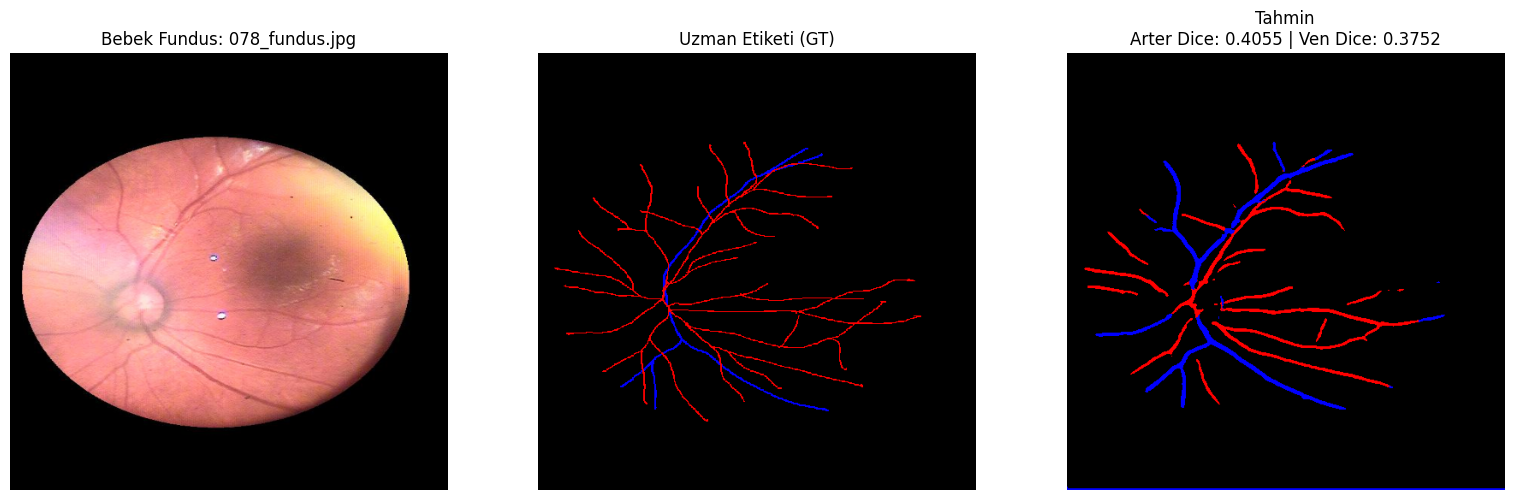

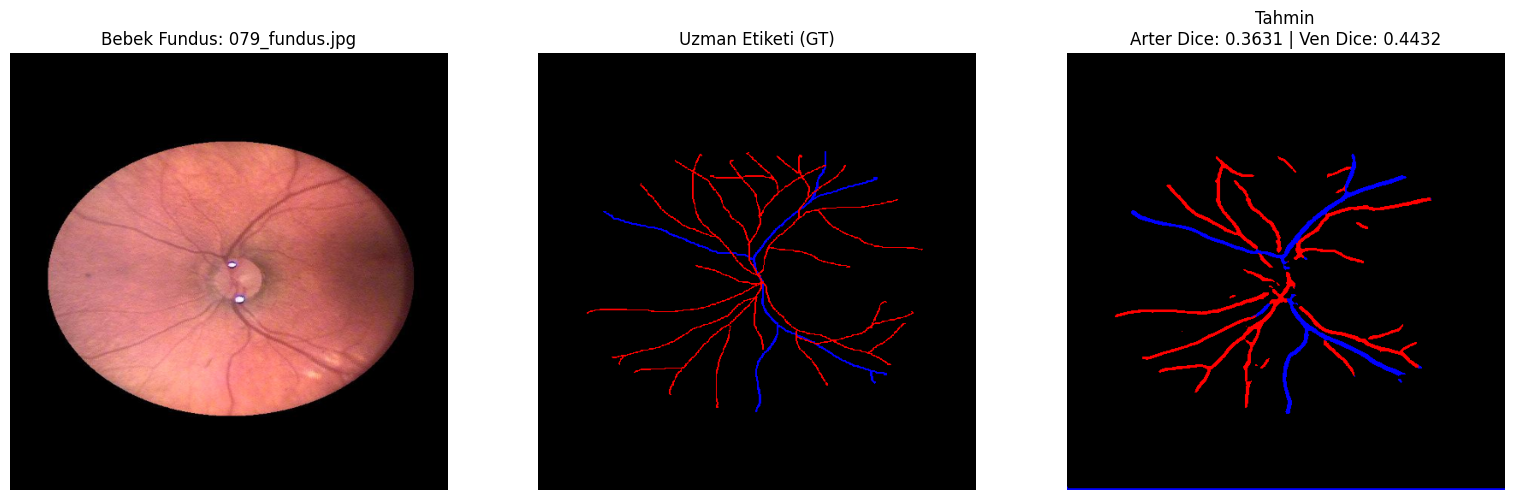

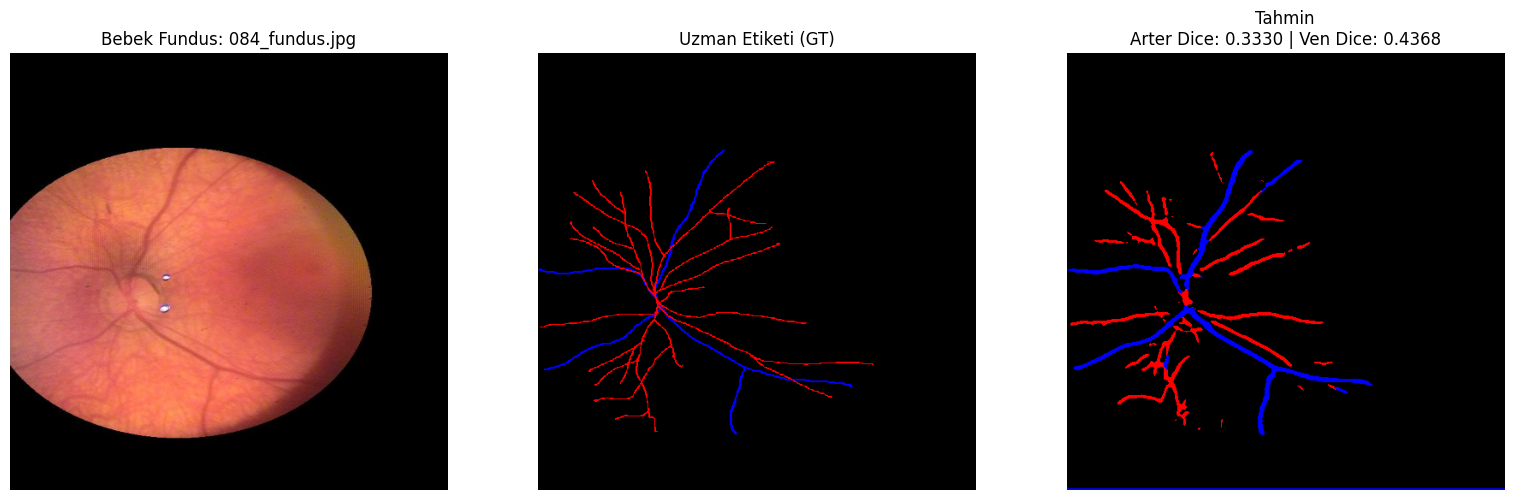

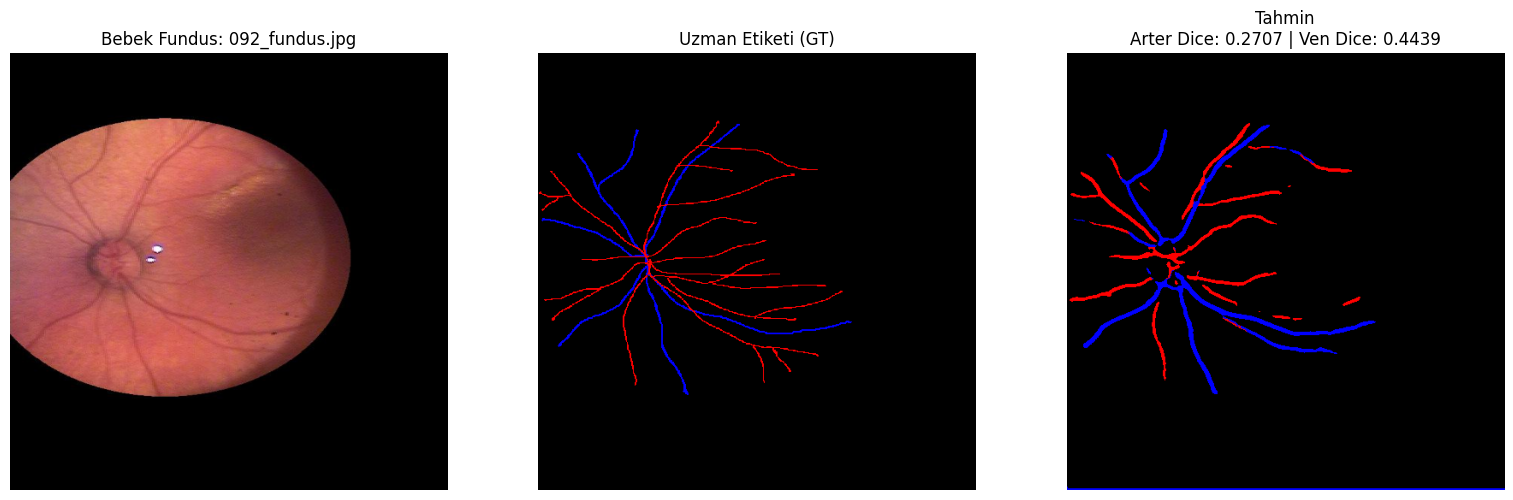

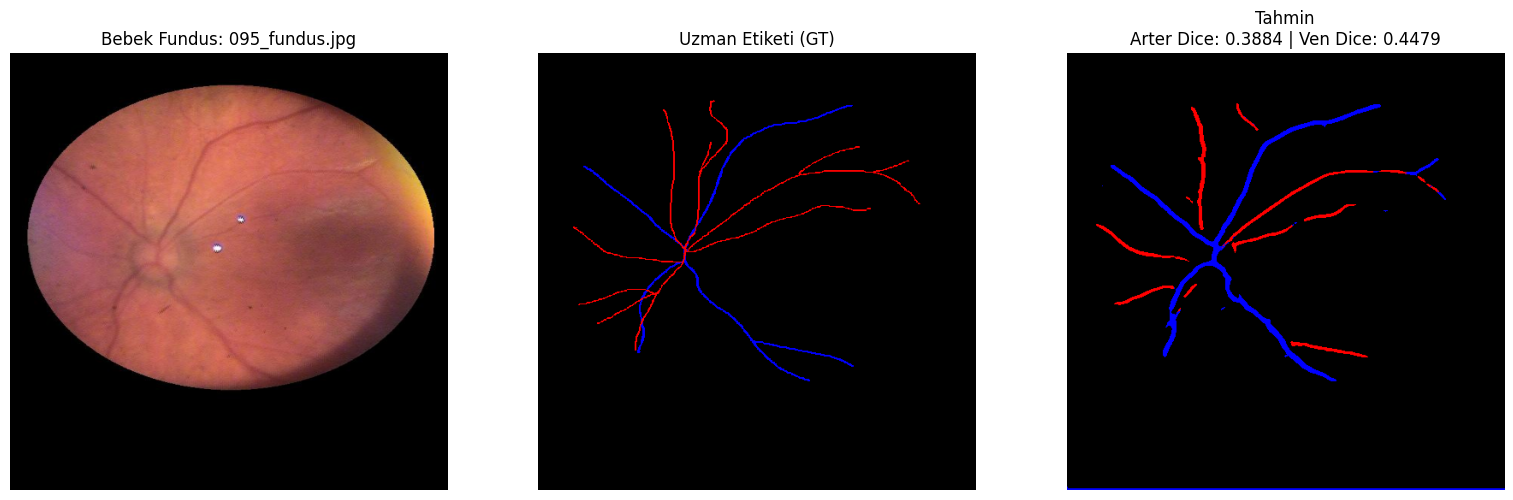

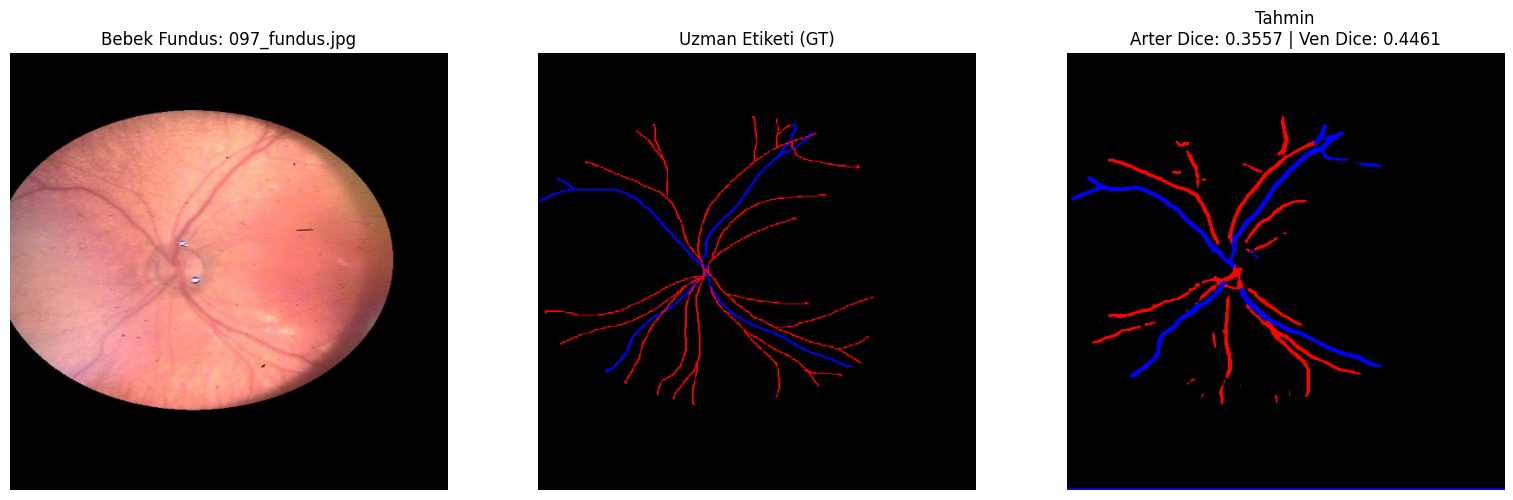

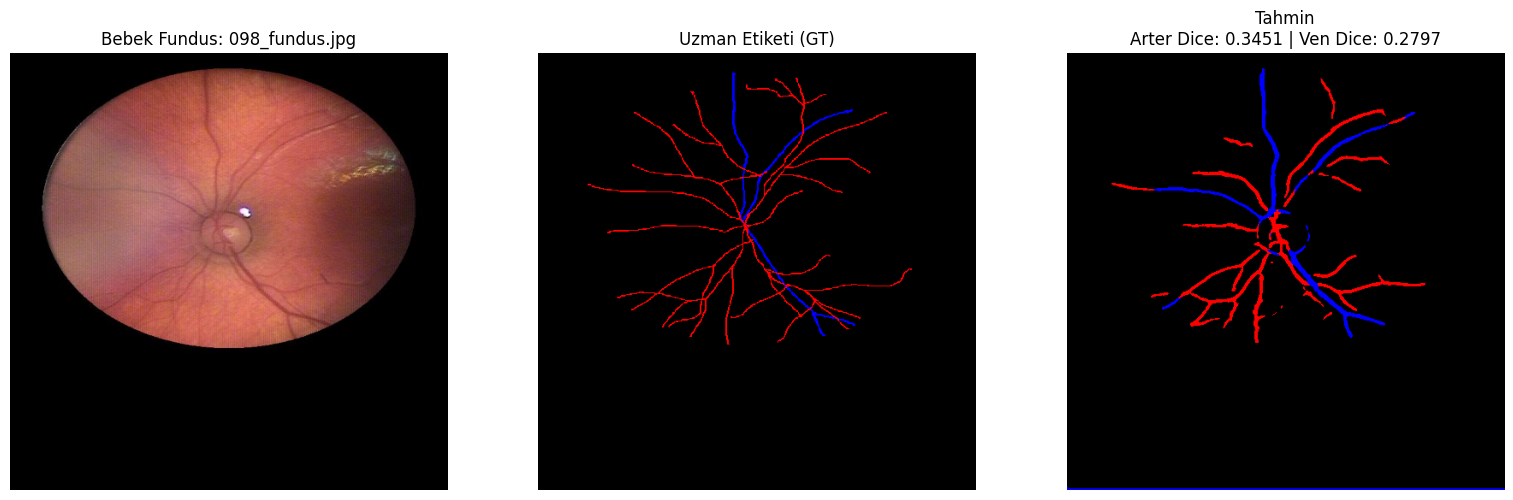

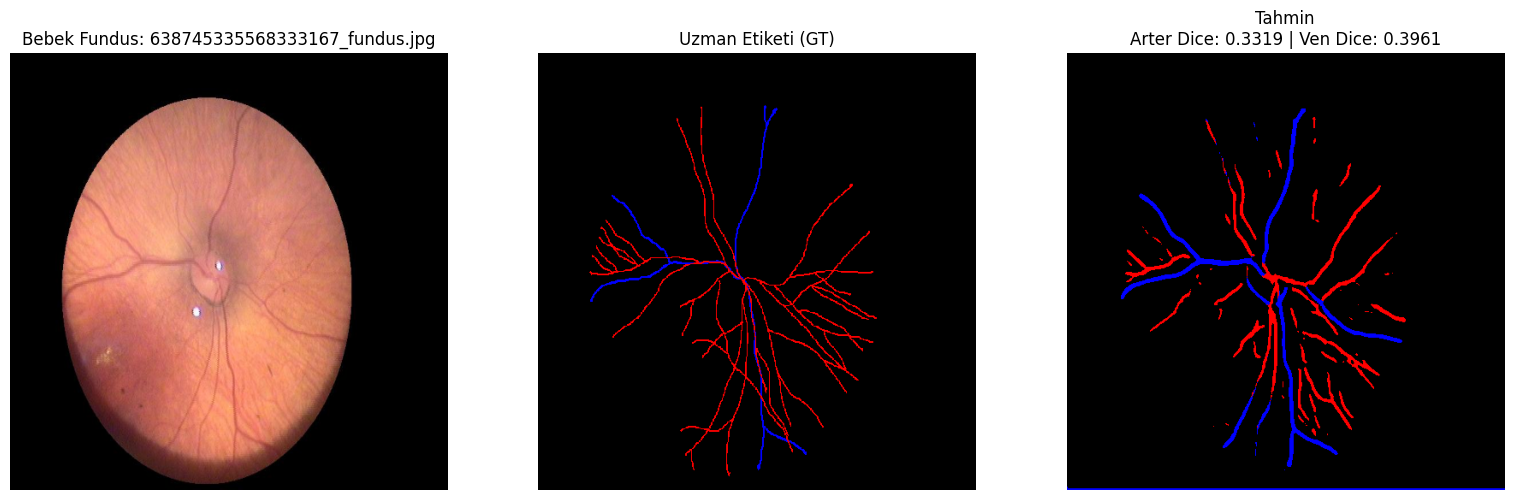

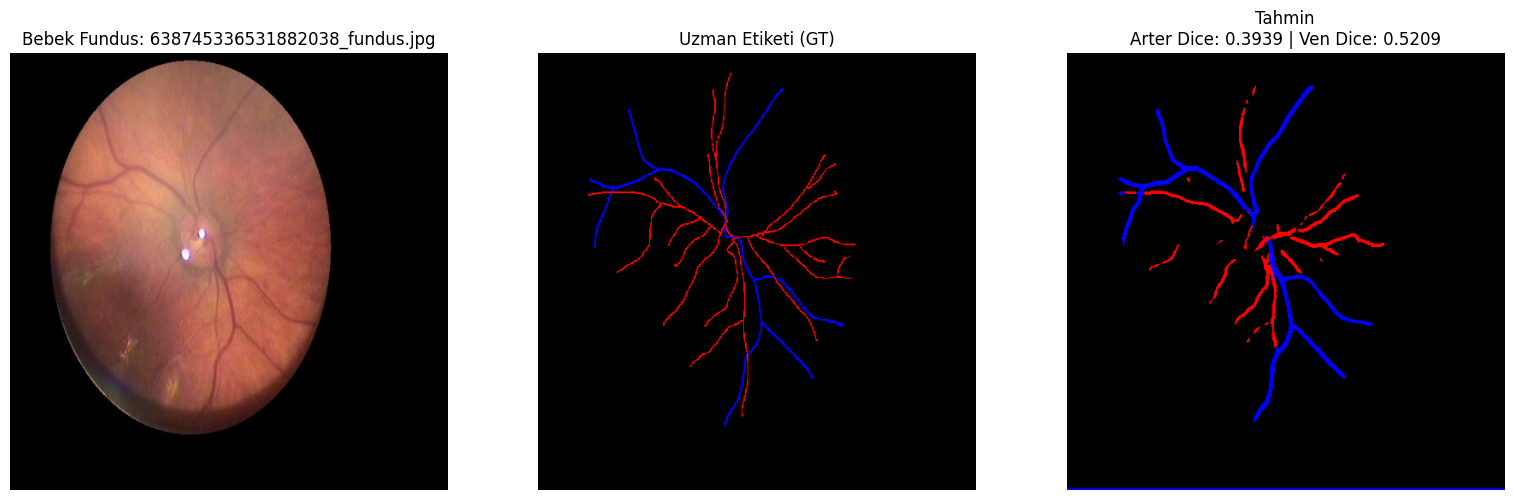

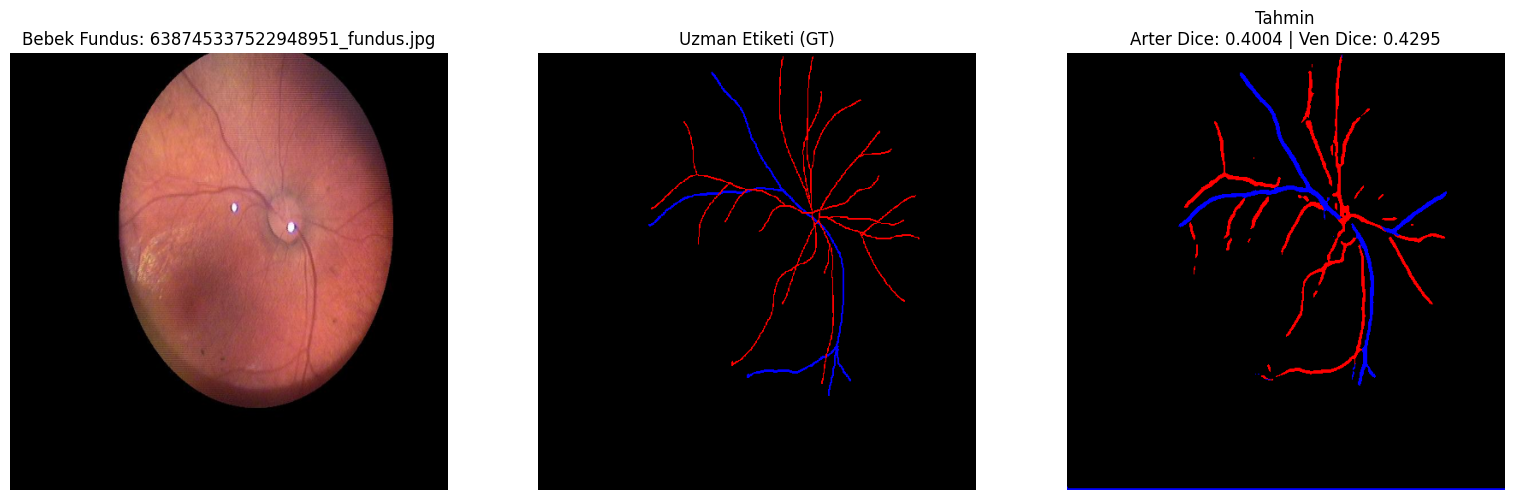

In [8]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import segmentation_models_pytorch as smp

# 1. Renk Düzeltme (Denormalizasyon)
# Orijinal fundus renklerini geri getirir 
def denormalize(img_tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img * std) + mean 
    return np.clip(img, 0, 1)

# 2. Bebek Datası Renk Haritası (0: Arka Plan, 1: Arter, 2: Ven) [cite: 86, 193]
infant_colors = {0: [0,0,0], 1: [255,0,0], 2: [0,0,255]}

def infant_mask_to_rgb(mask):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for cls, color in infant_colors.items():
        rgb[mask == cls] = color
    return rgb

# 3. Model Yükleme
model.load_state_dict(torch.load("best_bebek_infant_model2.pth"))
model.eval()

print(f"--- Bebek Datası Analizi (İlk 10 Örnek) ---")

with torch.no_grad():
    for i in range(min(10, len(val_ds))):
        image, mask = val_ds[i]
        input_tensor = image.unsqueeze(0).to(DEVICE)
        
        output = model(input_tensor)
        pred = torch.argmax(output, dim=1).squeeze(0)
        
        # Metrik İstatistikleri [cite: 178]
        # num_classes=3 (BG, Arter, Ven)
        tp, fp, fn, tn = smp.metrics.get_stats(
            pred.unsqueeze(0), # Batch boyutu ekle: [1, H, W]
            mask.unsqueeze(0).to(DEVICE).long(), 
            mode='multiclass', 
            num_classes=3
        )
        
        # HATA DÜZELTMESİ: reduction="micro" kullanarak boyut hatasını önlüyoruz
        # Artery (Sınıf 1) ve Vein (Sınıf 2) Dice Skorları [cite: 188]
        artery_dice = smp.metrics.f1_score(tp[:, 1], fp[:, 1], fn[:, 1], tn[:, 1], reduction="micro").item()
        vein_dice = smp.metrics.f1_score(tp[:, 2], fp[:, 2], fn[:, 2], tn[:, 2], reduction="micro").item()

        # Panel Oluşturma
        plt.figure(figsize=(16, 5))
        
        # Orijinal (Normalizasyon geri alınmış )
        plt.subplot(1, 3, 1)
        plt.title(f"Bebek Fundus: {val_ds.image_names[i]}")
        plt.imshow(denormalize(image))
        plt.axis('off')

        # Gerçek Etiket [cite: 148]
        plt.subplot(1, 3, 2)
        plt.title("Uzman Etiketi (GT)")
        plt.imshow(infant_mask_to_rgb(mask.numpy() if torch.is_tensor(mask) else mask))
        plt.axis('off')

        # Model Tahmini ve Skorlar 
        plt.subplot(1, 3, 3)
        plt.title(f"Tahmin\nArter Dice: {artery_dice:.4f} | Ven Dice: {vein_dice:.4f}")
        plt.imshow(infant_mask_to_rgb(pred.cpu().numpy()))
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()